# Model Training, Tuning & Over-fitting Control

*Companion notebook — the scripts in `src/` are the source of truth; this notebook loads and displays their outputs.*

In [1]:
import os, sys, warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..')); os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from config import *


## 1. Walk-forward hyper-parameter search
`python src/training/tune_models.py` — expanding-window folds on train+val only. Best parameters per asset/model:

In [2]:
import json; print(json.dumps(json.load(open(BEST_PARAMS_PATH)), indent=1))

{
 "return_1d": {
  "Bitcoin": {
   "Ridge": {
    "alpha": 100.0
   },
   "RandomForest": {
    "n_estimators": 300,
    "max_depth": 3,
    "min_samples_leaf": 30
   },
   "LightGBM": {
    "n_estimators": 600,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 0.0
   },
   "CatBoost": {
    "iterations": 800,
    "learning_rate": 0.03,
    "depth": 7,
    "l2_leaf_reg": 3.0
   },
   "GRU": {
    "units": 32,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": 40,
    "patience": 6
   },
   "LSTM": {
    "units": 32,
    "dropout": 0.4,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs": 40,
    "patience": 6
   }
  },
  "Gold": {
   "Ridge": {
    "alpha": 10.0
   },
   "RandomForest": {
    "n_estimators": 300,
    "max_depth": 3,
    "min_samples_leaf": 10
   },
   "LightGBM": {
    "n_estimators": 600,
    "learning_rate": 0.03,
    "num_leav

In [3]:
pd.read_csv(os.path.join(TUNING_DIR, 'tuning_summary.csv')).round(5)

,asset,model,RMSE_ret_mean,RMSE_ret_std,MAE_ret_mean,MAE_ret_std,R2_ret_mean,R2_ret_std,RMSE_usd_mean,RMSE_usd_std,DirAcc_pct_mean,DirAcc_pct_std,best_params
0,Bitcoin,Ridge,0.03161,0.00693,0.02135,0.00414,-0.00507,0.00283,1430.33747,435.81126,49.35567,1.89929,"{""alpha"": 100.0}"
1,Bitcoin,RandomForest,0.03160,0.00688,0.02140,0.00416,-0.00536,0.00555,1432.90172,433.81705,49.95704,2.40051,"{""n_estimators"": 300, ""max_depth"": 3, ""min_sam..."
2,Bitcoin,LightGBM,0.03158,0.00692,0.02140,0.00420,-0.00344,0.00412,1430.51610,432.69011,51.15979,1.73690,"{""n_estimators"": 600, ""learning_rate"": 0.03, ""..."
3,Bitcoin,CatBoost,0.03156,0.00695,0.02136,0.00415,-0.00131,0.00570,1427.06617,434.17045,50.21478,2.31601,"{""iterations"": 800, ""learning_rate"": 0.03, ""de..."
4,Bitcoin,GRU,0.03168,0.00697,0.02136,0.00418,-0.00897,0.00479,1432.61201,435.63222,49.39863,0.98329,"{""units"": 32, ""dropout"": 0.4, ""learning_rate"":..."
5,Bitcoin,LSTM,0.03170,0.00697,0.02142,0.00424,-0.01027,0.00503,1433.09348,436.33228,48.79725,0.70844,"{""units"": 32, ""dropout"": 0.4, ""learning_rate"":..."
6,Gold,Ridge,0.01112,0.00221,0.00787,0.00128,-0.00312,0.00753,28.34481,16.66274,52.09619,1.65385,"{""alpha"": 10.0}"
7,Gold,RandomForest,0.01114,0.00217,0.00792,0.00124,-0.00882,0.01183,28.38310,16.56741,53.22517,4.18839,"{""n_estimators"": 300, ""max_depth"": 3, ""min_sam..."
8,Gold,LightGBM,0.01112,0.00223,0.00788,0.00127,-0.00241,0.00491,28.40946,16.83060,52.60336,2.22139,"{""n_estimators"": 600, ""learning_rate"": 0.03, ""..."
9,Gold,CatBoost,0.01112,0.00223,0.00787,0.00127,-0.00295,0.00365,28.40324,16.78183,55.70434,2.76671,"{""iterations"": 800, ""learning_rate"": 0.01, ""de..."


## 2. Train vs validation performance (phase A of `train_models.py`)

In [4]:
tv = pd.read_csv(os.path.join(RESULTS_DIR, 'train_val_metrics.csv'))
tv.pivot_table(index=['asset','model'], columns='split', values='RMSE_ret').round(5)

split                   train      val
asset   model                         
Bitcoin CatBoost      0.03209  0.02604
        GRU           0.03361  0.02597
        LSTM          0.03358  0.02617
        LightGBM      0.02740  0.02539
        RandomForest  0.03299  0.02610
        Ridge         0.03352  0.02605
Gold    CatBoost      0.00896  0.02005
        GRU           0.00974  0.02019
        LSTM          0.00973  0.02024
        LightGBM      0.00958  0.02029
        RandomForest  0.00941  0.02007
        Ridge         0.00962  0.02015
Silver  CatBoost      0.01803  0.05515
        GRU           0.01917  0.05535
        LSTM          0.01919  0.05544
        LightGBM      0.01810  0.05490
        RandomForest  0.01866  0.05537
        Ridge         0.01913  0.05538

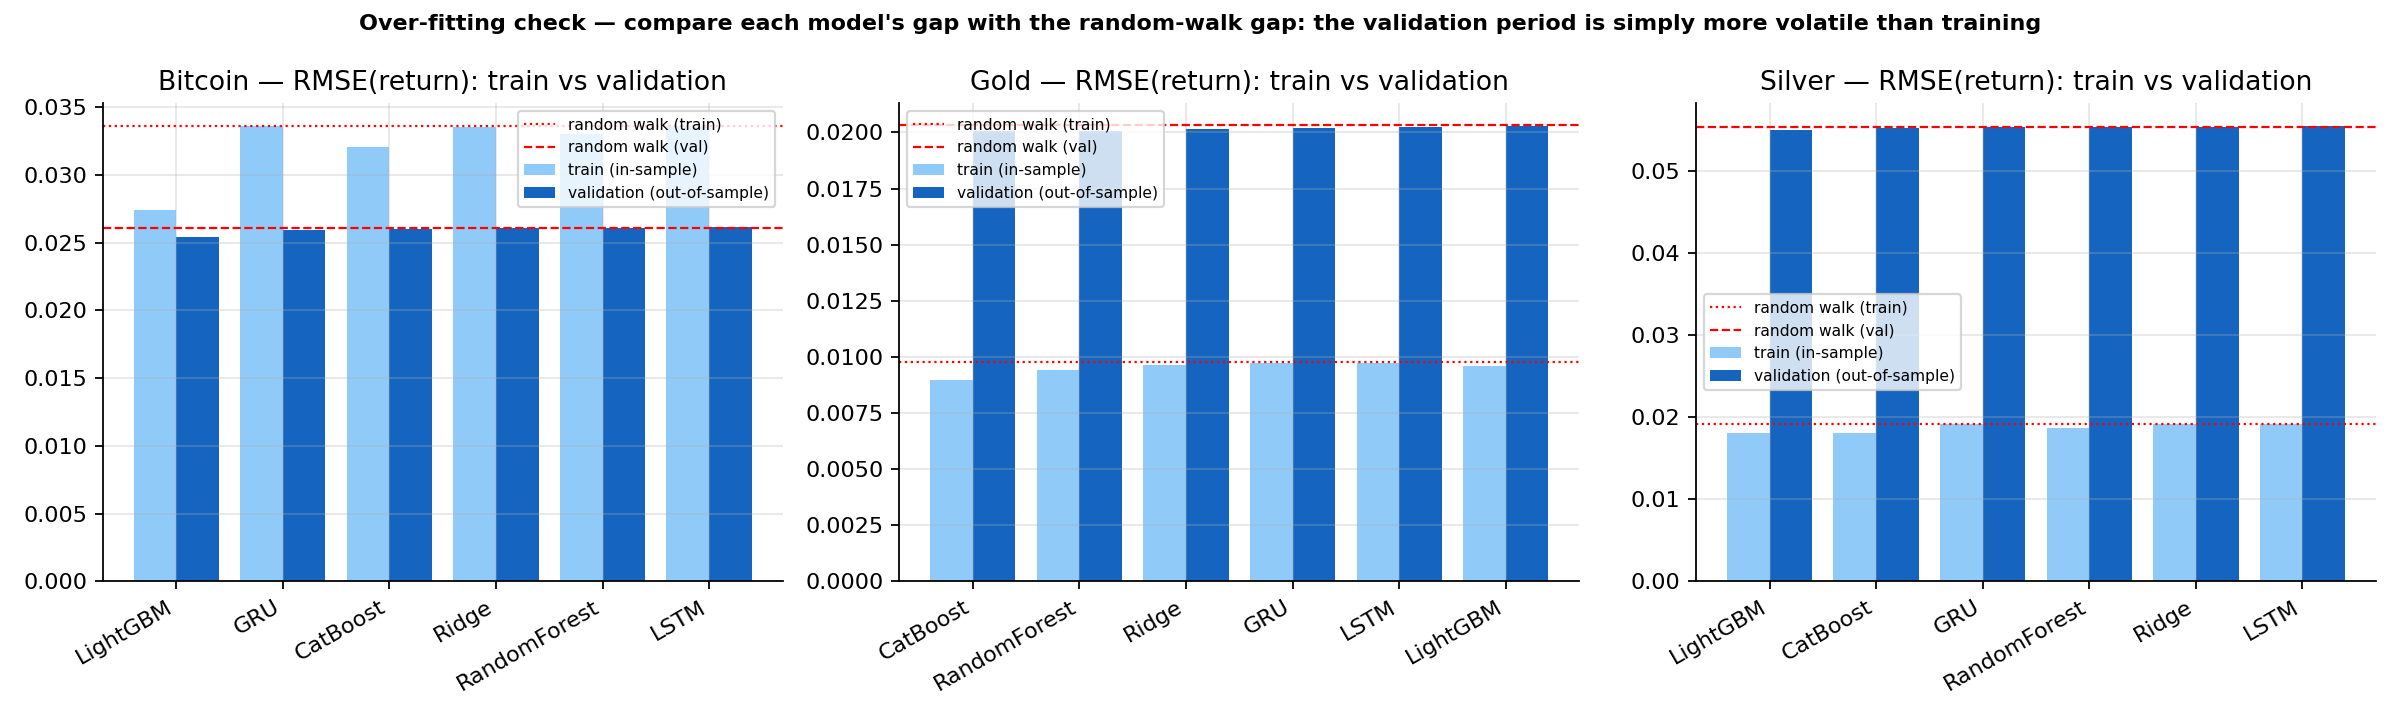

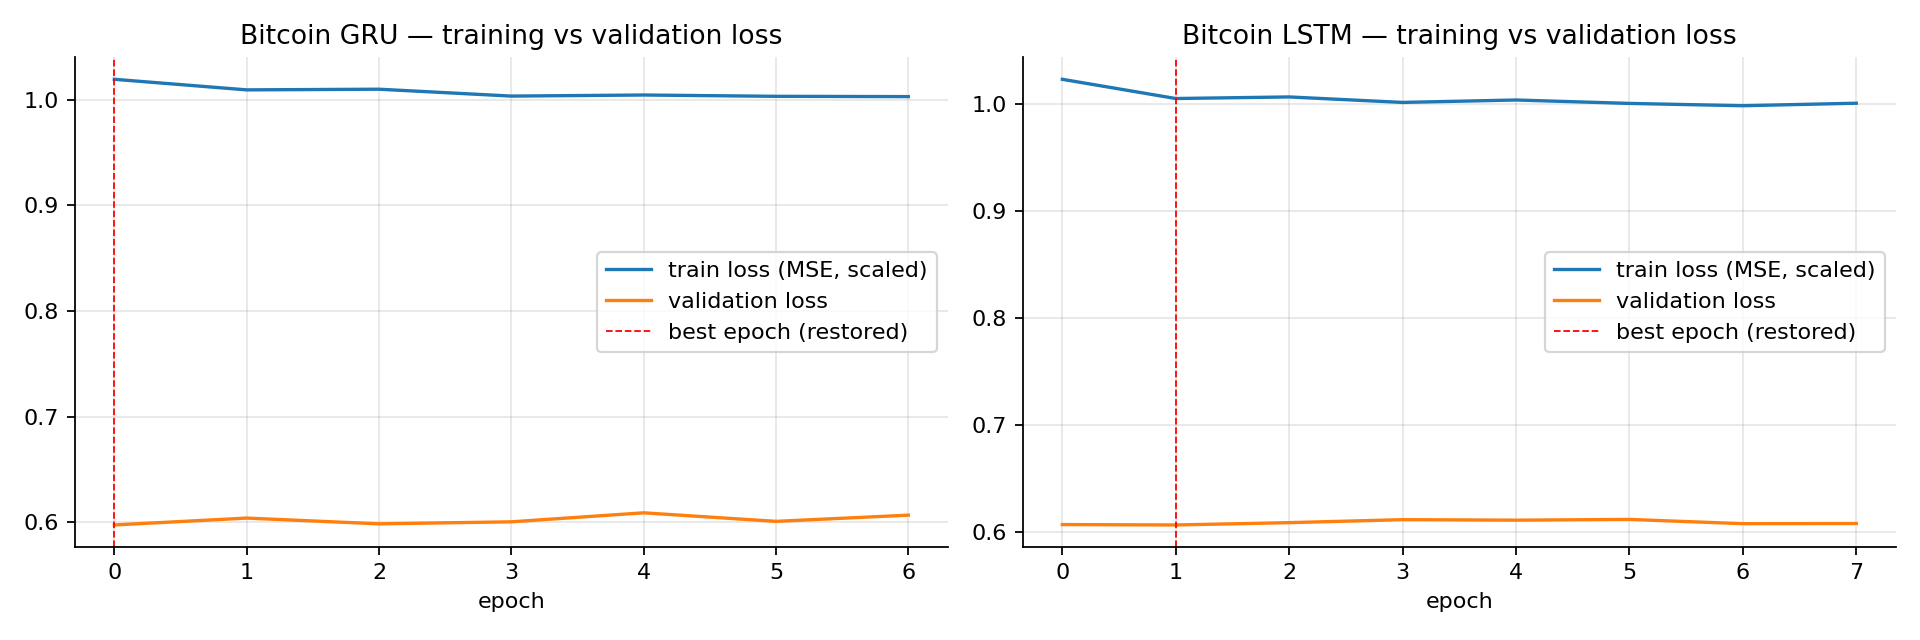

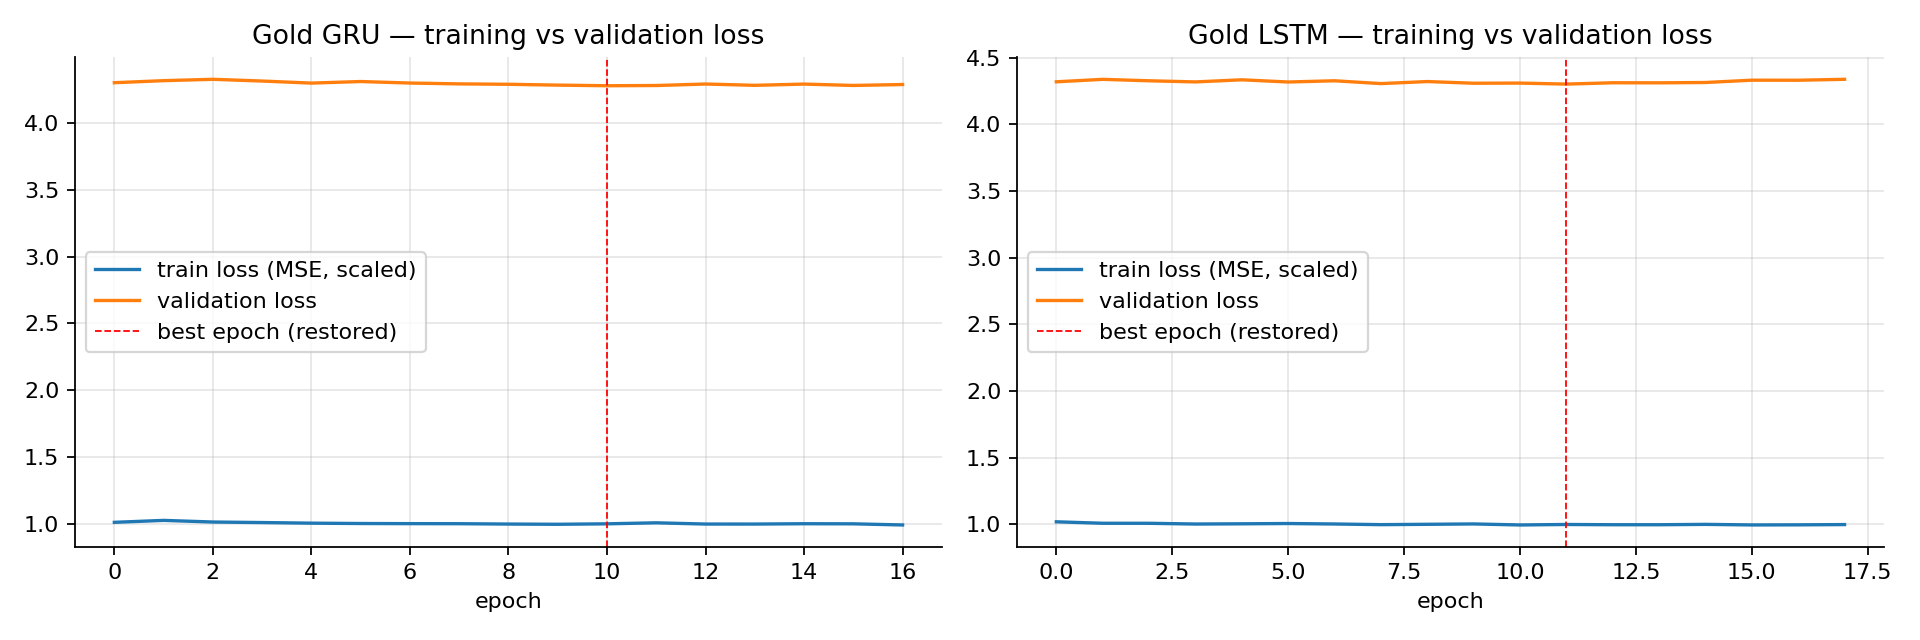

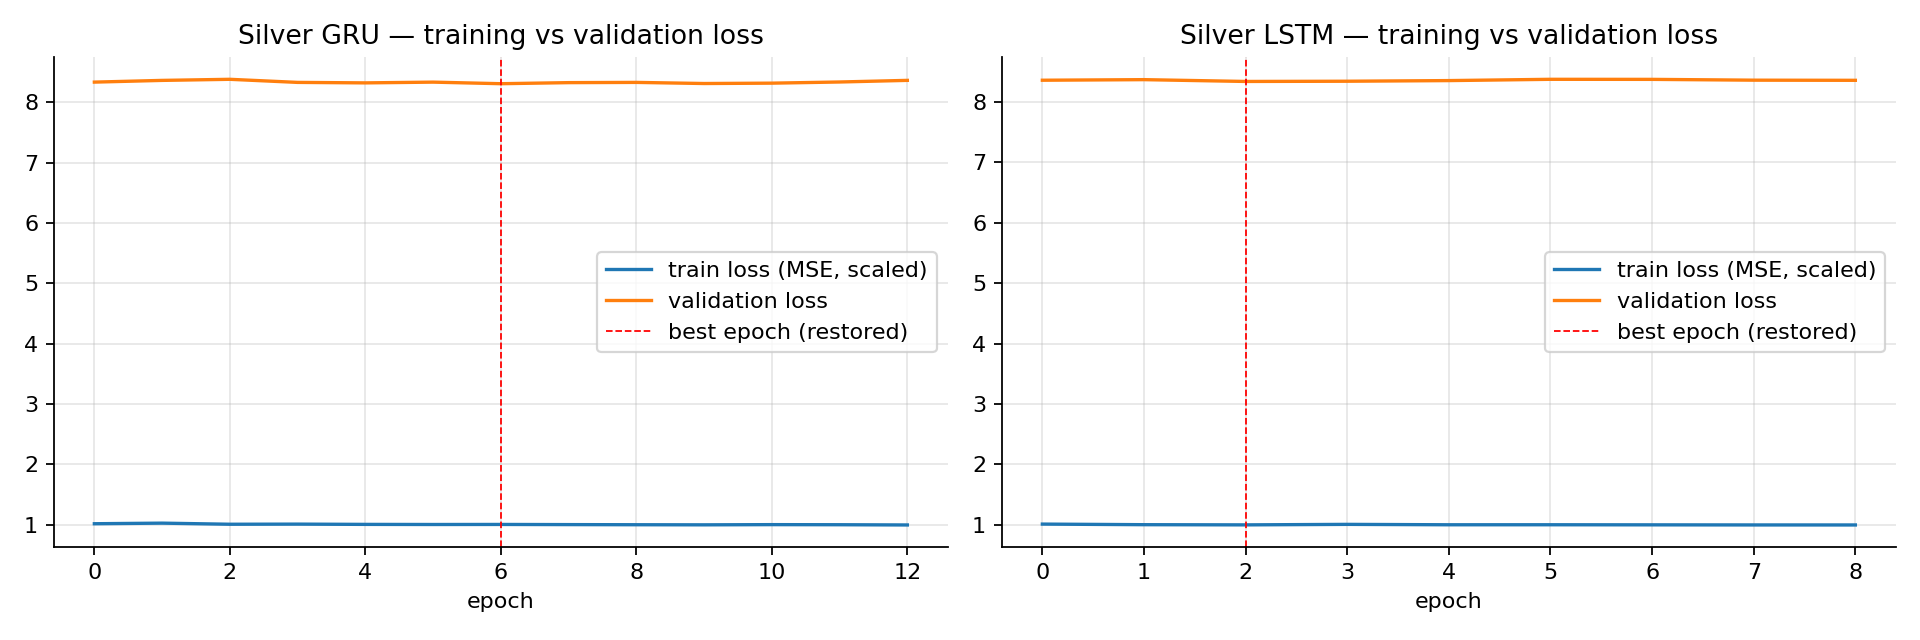

In [5]:
display(Image(os.path.join(FIGURES_DIR, 'overfitting_gap.png')))
for a in ASSETS:
    p = os.path.join(FIGURES_DIR, f'{get_prefix(a)}_loss_curves.png')
    if os.path.exists(p): display(Image(p))

## 3. Model architectures

In [6]:
from src.models.model_gru import build_gru_model
build_gru_model(SEQ_LEN, 24, units=32).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         5,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,113 (23.88 KB)

 Trainable params: 6,113 (23.88 KB)

 Non-trainable params: 0 (0.00 B)